"""
Notebook 06 - Seller ESG Modeling

Objectives
----------
This notebook builds the Seller ESG Assessment Model.

The model consists of:

1. AHP-based ESG indicator weighting
2. Seller ESG Reference Score generation
3. Machine Learning-based ESG score approximation and validation
4. ESG indicator importance interpretation

Main outputs
------------
- ahp_indicator_mapping.csv
- indicator_weight.csv
- seller_esg_reference_dataset.csv
- model_performance.csv
- feature_importance.csv
- seller_esg_model.pkl
"""

In [69]:
from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [70]:
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print(
        "XGBoost is not installed. "
        "Run: pip install xgboost"
    )

In [71]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "Dataset" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_DIR = PROJECT_ROOT / "Dataset" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "ESG_Modeling"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_DATASET_PATH = INPUT_DIR / "seller_esg_feature_dataset.csv"

MAPPING_OUTPUT_PATH = OUTPUT_DIR / "ahp_indicator_mapping.csv"
WEIGHT_OUTPUT_PATH = OUTPUT_DIR / "indicator_weight.csv"
REFERENCE_OUTPUT_PATH = OUTPUT_DIR / "seller_esg_reference_dataset.csv"
PERFORMANCE_OUTPUT_PATH = OUTPUT_DIR / "model_performance.csv"
IMPORTANCE_OUTPUT_PATH = OUTPUT_DIR / "feature_importance.csv"
MODEL_OUTPUT_PATH = OUTPUT_DIR / "seller_esg_model.pkl"

In [72]:
if not FEATURE_DATASET_PATH.exists():
    candidate_paths = [FEATURE_DATASET_PATH]
    candidate_paths.extend(PROJECT_ROOT.rglob("seller_esg_feature_dataset.csv"))

    resolved_path = next(
        (path for path in candidate_paths if path.exists()),
        None,
    )

    if resolved_path is None:
        raise FileNotFoundError(
            "Input dataset not found. Checked:\n"
            + "\n".join(f"- {path}" for path in candidate_paths)
        )

    FEATURE_DATASET_PATH = resolved_path

seller_esg_df = pd.read_csv(FEATURE_DATASET_PATH)

print("Dataset shape:", seller_esg_df.shape)
display(seller_esg_df.head())

Dataset shape: (261, 10)


,seller_name,environmental_keyword_count,sustainable_material_count,eco_label_count,product_quality_complaint_count,product_damage_complaint_count,product_safety_complaint_count,customer_service_complaint_count,counterfeit_complaint_count,governance_keyword_count
0,101Dealz,0.0,1.666667,0.0,0.0,0.033333,0.066667,0.0,0.0,0.5
1,123(EXOPRT WAREHOUSE),0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0
2,24 Caret,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.1
3,"33,000ft outdoor",0.0,1.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0
4,5Mayi Official,0.0,1.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0


In [73]:
seller_esg_df.info()

display(seller_esg_df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   seller_name                       261 non-null    str    
 1   environmental_keyword_count       261 non-null    float64
 2   sustainable_material_count        261 non-null    float64
 3   eco_label_count                   261 non-null    float64
 4   product_quality_complaint_count   261 non-null    float64
 5   product_damage_complaint_count    261 non-null    float64
 6   product_safety_complaint_count    261 non-null    float64
 7   customer_service_complaint_count  261 non-null    float64
 8   counterfeit_complaint_count       261 non-null    float64
 9   governance_keyword_count          261 non-null    float64
dtypes: float64(9), str(1)
memory usage: 23.4 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_name,261,261,101Dealz,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
environmental_keyword_count,261.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sustainable_material_count,261.0,NaN,NaN,NaN,0.582712,0.692379,0.0,0.0,0.342105,1.0,3.0
eco_label_count,261.0,NaN,NaN,NaN,0.003923,0.06191,0.0,0.0,0.0,0.0,1.0
product_quality_complaint_count,261.0,NaN,NaN,NaN,0.008103,0.029385,0.0,0.0,0.0,0.0,0.2
product_damage_complaint_count,261.0,NaN,NaN,NaN,0.006795,0.041169,0.0,0.0,0.0,0.0,0.5
product_safety_complaint_count,261.0,NaN,NaN,NaN,0.00272,0.017313,0.0,0.0,0.0,0.0,0.2
customer_service_complaint_count,261.0,NaN,NaN,NaN,0.002676,0.01755,0.0,0.0,0.0,0.0,0.181818
counterfeit_complaint_count,261.0,NaN,NaN,NaN,0.001005,0.009275,0.0,0.0,0.0,0.0,0.1
governance_keyword_count,261.0,NaN,NaN,NaN,0.727755,0.361185,0.0,0.4,1.0,1.0,1.0


In [74]:
SELLER_COLUMN_CANDIDATES = [
    "seller",
    "seller_name",
    "seller_id",
    "shop_name",
    "shop_id",
]

seller_column = next(
    (
        column
        for column in SELLER_COLUMN_CANDIDATES
        if column in seller_esg_df.columns
    ),
    None,
)

if seller_column is None:
    raise ValueError(
        "Seller identifier column was not found. "
        f"Expected one of: {SELLER_COLUMN_CANDIDATES}"
    )

print("Seller identifier column:", seller_column)

Seller identifier column: seller_name


In [75]:
indicator_mapping = pd.DataFrame(
    [
        {
            "feature": "sustainable_material_count",
            "indicator": "Sustainable Material Adoption",
            "dimension": "Environmental",
            "dimension_code": "E",
        },
        {
            "feature": "eco_label_count",
            "indicator": "Eco Label Adoption",
            "dimension": "Environmental",
            "dimension_code": "E",
        },
        {
            "feature": "environmental_keyword_count",
            "indicator": "Environmental Commitment",
            "dimension": "Environmental",
            "dimension_code": "E",
        },
        {
            "feature": "product_quality_complaint_count",
            "indicator": "Product Quality Responsibility",
            "dimension": "Social",
            "dimension_code": "S",
        },
        {
            "feature": "product_damage_complaint_count",
            "indicator": "Product Durability",
            "dimension": "Social",
            "dimension_code": "S",
        },
        {
            "feature": "product_safety_complaint_count",
            "indicator": "Product Safety Responsibility",
            "dimension": "Social",
            "dimension_code": "S",
        },
        {
            "feature": "customer_service_complaint_count",
            "indicator": "Customer Relationship Management",
            "dimension": "Governance",
            "dimension_code": "G",
        },
        {
            "feature": "counterfeit_complaint_count",
            "indicator": "Business Integrity",
            "dimension": "Governance",
            "dimension_code": "G",
        },
        {
            "feature": "governance_keyword_count",
            "indicator": "Transparency Responsibility",
            "dimension": "Governance",
            "dimension_code": "G",
        },
    ]
)

display(indicator_mapping)

,feature,indicator,dimension,dimension_code
0,sustainable_material_count,Sustainable Material Adoption,Environmental,E
1,eco_label_count,Eco Label Adoption,Environmental,E
2,environmental_keyword_count,Environmental Commitment,Environmental,E
3,product_quality_complaint_count,Product Quality Responsibility,Social,S
4,product_damage_complaint_count,Product Durability,Social,S
5,product_safety_complaint_count,Product Safety Responsibility,Social,S
6,customer_service_complaint_count,Customer Relationship Management,Governance,G
7,counterfeit_complaint_count,Business Integrity,Governance,G
8,governance_keyword_count,Transparency Responsibility,Governance,G


In [76]:
required_features = indicator_mapping["feature"].tolist()

missing_features = [
    feature
    for feature in required_features
    if feature not in seller_esg_df.columns
]

if missing_features:
    raise ValueError(
        "The following ESG features are missing from the dataset:\n"
        + "\n".join(f"- {feature}" for feature in missing_features)
    )

print("All nine ESG operational indicators are available.")

All nine ESG operational indicators are available.


In [77]:
indicator_mapping.to_csv(
    MAPPING_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", MAPPING_OUTPUT_PATH)

Saved: d:\UNI\NCKH\CTD2026_DT049\ESG_Modeling\ahp_indicator_mapping.csv


In [78]:
RI_TABLE = {
    1: 0.00,
    2: 0.00,
    3: 0.58,
    4: 0.90,
    5: 1.12,
    6: 1.24,
    7: 1.32,
    8: 1.41,
    9: 1.45,
    10: 1.49,
}


def calculate_ahp_weights(
    pairwise_matrix: np.ndarray,
    labels: list[str],
) -> tuple[pd.DataFrame, dict]:
    """
    Calculate AHP weights using the principal eigenvector method.

    Parameters
    ----------
    pairwise_matrix:
        Positive reciprocal pairwise comparison matrix.
    labels:
        Criterion labels in the same order as the matrix.

    Returns
    -------
    weight_df:
        DataFrame containing criterion weights.
    consistency:
        Dictionary containing lambda_max, CI, RI and CR.
    """
    matrix = np.asarray(pairwise_matrix, dtype=float)
    n = matrix.shape[0]

    if matrix.shape != (n, n):
        raise ValueError("Pairwise comparison matrix must be square.")

    if len(labels) != n:
        raise ValueError("Number of labels must match matrix size.")

    if np.any(matrix <= 0):
        raise ValueError("All matrix values must be positive.")

    reciprocal_check = np.allclose(
        matrix * matrix.T,
        np.ones_like(matrix),
        atol=1e-5,
    )

    if not reciprocal_check:
        raise ValueError(
            "Pairwise comparison matrix must be reciprocal."
        )

    eigenvalues, eigenvectors = np.linalg.eig(matrix)

    max_index = np.argmax(eigenvalues.real)
    lambda_max = eigenvalues.real[max_index]

    principal_vector = np.abs(eigenvectors[:, max_index].real)
    weights = principal_vector / principal_vector.sum()

    ci = 0.0 if n <= 2 else (lambda_max - n) / (n - 1)
    ri = RI_TABLE.get(n, np.nan)
    cr = 0.0 if ri == 0 else ci / ri

    weight_df = pd.DataFrame(
        {
            "criterion": labels,
            "local_weight": weights,
        }
    )

    consistency = {
        "n": n,
        "lambda_max": float(lambda_max),
        "CI": float(ci),
        "RI": float(ri),
        "CR": float(cr),
        "consistent": bool(cr < 0.10),
    }

    return weight_df, consistency

In [79]:
dimension_labels = [
    "Environmental",
    "Social",
    "Governance",
]

dimension_pairwise_matrix = np.array(
    [
        [1,   2,   2],
        [1/2, 1, 1/2],
        [1/2, 2,   1],
    ]
)

dimension_weights, dimension_consistency = calculate_ahp_weights(
    dimension_pairwise_matrix,
    dimension_labels,
)

display(dimension_weights)
dimension_consistency

,criterion,local_weight
0,Environmental,0.493386
1,Social,0.195800
2,Governance,0.310814


{'n': 3,
 'lambda_max': 3.0536215758789726,
 'CI': 0.026810787939486325,
 'RI': 0.58,
 'CR': 0.04622549644739022,
 'consistent': True}

In [80]:
environmental_labels = [
    "Sustainable Material Adoption",
    "Eco Label Adoption",
    "Environmental Commitment",
]

environmental_matrix = np.array(
    [
        [1,   2,   3],
        [1/2, 1,   2],
        [1/3, 1/2, 1],
    ]
)

environmental_weights, environmental_consistency = (
    calculate_ahp_weights(
        environmental_matrix,
        environmental_labels,
    )
)

display(environmental_weights)
environmental_consistency

,criterion,local_weight
0,Sustainable Material Adoption,0.539615
1,Eco Label Adoption,0.296961
2,Environmental Commitment,0.163424


{'n': 3,
 'lambda_max': 3.009202712714283,
 'CI': 0.004601356357141428,
 'RI': 0.58,
 'CR': 0.007933373029554188,
 'consistent': True}

In [81]:
environmental_labels = [
    "Sustainable Material Adoption",
    "Eco Label Adoption",
    "Environmental Commitment",
]

environmental_matrix = np.array(
    [
        [1,   2,   3],
        [1/2, 1,   2],
        [1/3, 1/2, 1],
    ]
)

environmental_weights, environmental_consistency = (
    calculate_ahp_weights(
        environmental_matrix,
        environmental_labels,
    )
)

display(environmental_weights)
environmental_consistency

,criterion,local_weight
0,Sustainable Material Adoption,0.539615
1,Eco Label Adoption,0.296961
2,Environmental Commitment,0.163424


{'n': 3,
 'lambda_max': 3.009202712714283,
 'CI': 0.004601356357141428,
 'RI': 0.58,
 'CR': 0.007933373029554188,
 'consistent': True}

In [82]:
social_labels = [
    "Product Quality Responsibility",
    "Product Durability",
    "Product Safety Responsibility",
]

social_matrix = np.array(
    [
        [1,   2,   1],
        [1/2, 1, 1/2],
        [1,   2,   1],
    ]
)

social_weights, social_consistency = calculate_ahp_weights(
    social_matrix,
    social_labels,
)

display(social_weights)
social_consistency

,criterion,local_weight
0,Product Quality Responsibility,0.4
1,Product Durability,0.2
2,Product Safety Responsibility,0.4


{'n': 3,
 'lambda_max': 2.999999999999999,
 'CI': -4.440892098500626e-16,
 'RI': 0.58,
 'CR': -7.656710514656253e-16,
 'consistent': True}

In [83]:
governance_labels = [
    "Customer Relationship Management",
    "Business Integrity",
    "Transparency Responsibility",
]

governance_matrix = np.array(
    [
        [1,   1/2, 1],
        [2,   1,   2],
        [1,   1/2, 1],
    ]
)

governance_weights, governance_consistency = (
    calculate_ahp_weights(
        governance_matrix,
        governance_labels,
    )
)

display(governance_weights)
governance_consistency

,criterion,local_weight
0,Customer Relationship Management,0.25
1,Business Integrity,0.50
2,Transparency Responsibility,0.25


{'n': 3,
 'lambda_max': 2.999999999999999,
 'CI': -4.440892098500626e-16,
 'RI': 0.58,
 'CR': -7.656710514656253e-16,
 'consistent': True}

In [84]:
consistency_results = pd.DataFrame(
    [
        {
            "level": "ESG Dimensions",
            **dimension_consistency,
        },
        {
            "level": "Environmental Indicators",
            **environmental_consistency,
        },
        {
            "level": "Social Indicators",
            **social_consistency,
        },
        {
            "level": "Governance Indicators",
            **governance_consistency,
        },
    ]
)

display(consistency_results)

,level,n,lambda_max,CI,RI,CR,consistent
0,ESG Dimensions,3,3.053622,2.681079e-02,0.58,4.622550e-02,True
1,Environmental Indicators,3,3.009203,4.601356e-03,0.58,7.933373e-03,True
2,Social Indicators,3,3.000000,-4.440892e-16,0.58,-7.656711e-16,True
3,Governance Indicators,3,3.000000,-4.440892e-16,0.58,-7.656711e-16,True


In [85]:
if not consistency_results["consistent"].all():
    print(
        "Warning: At least one AHP matrix has CR >= 0.10. "
        "The expert comparisons should be reviewed."
    )
else:
    print("All pairwise comparison matrices have CR < 0.10.")

All pairwise comparison matrices have CR < 0.10.


In [86]:
dimension_weight_dict = dict(
    zip(
        dimension_weights["criterion"],
        dimension_weights["local_weight"],
    )
)

local_indicator_weights = pd.concat(
    [
        environmental_weights.assign(
            dimension="Environmental",
            dimension_code="E",
        ),
        social_weights.assign(
            dimension="Social",
            dimension_code="S",
        ),
        governance_weights.assign(
            dimension="Governance",
            dimension_code="G",
        ),
    ],
    ignore_index=True,
)

local_indicator_weights = local_indicator_weights.rename(
    columns={"criterion": "indicator"}
)

local_indicator_weights["dimension_weight"] = (
    local_indicator_weights["dimension"]
    .map(dimension_weight_dict)
)

local_indicator_weights["global_weight"] = (
    local_indicator_weights["local_weight"]
    * local_indicator_weights["dimension_weight"]
)

indicator_weight_df = indicator_mapping.merge(
    local_indicator_weights,
    on=[
        "indicator",
        "dimension",
        "dimension_code",
    ],
    how="left",
)

indicator_weight_df["global_weight"] = (
    indicator_weight_df["global_weight"]
    / indicator_weight_df["global_weight"].sum()
)

display(
    indicator_weight_df[
        [
            "feature",
            "indicator",
            "dimension",
            "local_weight",
            "dimension_weight",
            "global_weight",
        ]
    ].sort_values(
        "global_weight",
        ascending=False,
    )
)

,feature,indicator,dimension,local_weight,dimension_weight,global_weight
0,sustainable_material_count,Sustainable Material Adoption,Environmental,0.539615,0.493386,0.266238
7,counterfeit_complaint_count,Business Integrity,Governance,0.500000,0.310814,0.155407
1,eco_label_count,Eco Label Adoption,Environmental,0.296961,0.493386,0.146517
2,environmental_keyword_count,Environmental Commitment,Environmental,0.163424,0.493386,0.080631
3,product_quality_complaint_count,Product Quality Responsibility,Social,0.400000,0.195800,0.078320
5,product_safety_complaint_count,Product Safety Responsibility,Social,0.400000,0.195800,0.078320
6,customer_service_complaint_count,Customer Relationship Management,Governance,0.250000,0.310814,0.077703
8,governance_keyword_count,Transparency Responsibility,Governance,0.250000,0.310814,0.077703
4,product_damage_complaint_count,Product Durability,Social,0.200000,0.195800,0.039160


In [87]:
indicator_weight_df.to_csv(
    WEIGHT_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Total global weight:", indicator_weight_df["global_weight"].sum())
print("Saved:", WEIGHT_OUTPUT_PATH)

Total global weight: 1.0
Saved: d:\UNI\NCKH\CTD2026_DT049\ESG_Modeling\indicator_weight.csv


In [88]:
esg_features = indicator_weight_df["feature"].tolist()

indicator_data = seller_esg_df[
    [seller_column] + esg_features
].copy()

In [89]:
for feature in esg_features:
    indicator_data[feature] = pd.to_numeric(
        indicator_data[feature],
        errors="coerce",
    )

missing_summary = (
    indicator_data[esg_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary.rename("missing_values").to_frame()
)

,missing_values
sustainable_material_count,0
eco_label_count,0
environmental_keyword_count,0
product_quality_complaint_count,0
product_damage_complaint_count,0
product_safety_complaint_count,0
customer_service_complaint_count,0
counterfeit_complaint_count,0
governance_keyword_count,0


In [90]:
imputer = SimpleImputer(strategy="median")

imputed_values = imputer.fit_transform(
    indicator_data[esg_features]
)

imputed_df = pd.DataFrame(
    imputed_values,
    columns=esg_features,
    index=indicator_data.index,
)

In [91]:
scaler = MinMaxScaler()

normalized_values = scaler.fit_transform(
    imputed_df[esg_features]
)

normalized_indicator_df = pd.DataFrame(
    normalized_values,
    columns=esg_features,
    index=indicator_data.index,
)

normalized_indicator_df.insert(
    0,
    seller_column,
    indicator_data[seller_column].values,
)

display(normalized_indicator_df.head())

,seller_name,sustainable_material_count,eco_label_count,environmental_keyword_count,product_quality_complaint_count,product_damage_complaint_count,product_safety_complaint_count,customer_service_complaint_count,counterfeit_complaint_count,governance_keyword_count
0,101Dealz,0.555556,0.0,0.0,0.0,0.066667,0.333333,0.0,0.0,0.5
1,123(EXOPRT WAREHOUSE),0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0
2,24 Caret,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.1
3,"33,000ft outdoor",0.333333,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0
4,5Mayi Official,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0


In [92]:
negative_direction_features = [
    "environmental_keyword_count",
    "product_quality_complaint_count",
    "product_damage_complaint_count",
    "product_safety_complaint_count",
    "customer_service_complaint_count",
    "counterfeit_complaint_count",
    "governance_keyword_count",
]

for feature in negative_direction_features:
    if feature in normalized_indicator_df.columns:
        normalized_indicator_df[feature] = (
            1 - normalized_indicator_df[feature]
        )

In [93]:
reference_df = normalized_indicator_df.copy()

for dimension_code in ["E", "S", "G"]:
    dimension_items = indicator_weight_df[
        indicator_weight_df["dimension_code"] == dimension_code
    ].copy()

    dimension_features = dimension_items["feature"].tolist()
    local_weights = dimension_items.set_index(
        "feature"
    )["local_weight"]

    reference_df[f"{dimension_code}_score"] = sum(
        reference_df[feature] * local_weights[feature]
        for feature in dimension_features
    )

In [94]:
reference_df["ESG_reference_score"] = (
    reference_df["E_score"]
    * dimension_weight_dict["Environmental"]
    + reference_df["S_score"]
    * dimension_weight_dict["Social"]
    + reference_df["G_score"]
    * dimension_weight_dict["Governance"]
)

In [95]:
global_weight_check = sum(
    reference_df[row["feature"]] * row["global_weight"]
    for _, row in indicator_weight_df.iterrows()
)

assert np.allclose(
    reference_df["ESG_reference_score"],
    global_weight_check,
    atol=1e-8,
)

print("Dimension-based and global-weight calculations are consistent.")

Dimension-based and global-weight calculations are consistent.


In [96]:
def assign_esg_level(score: float) -> str:
    if score >= 0.80:
        return "Excellent"
    if score >= 0.65:
        return "Good"
    if score >= 0.50:
        return "Moderate"
    if score >= 0.35:
        return "Weak"
    return "Very Weak"


reference_df["ESG_level"] = (
    reference_df["ESG_reference_score"]
    .apply(assign_esg_level)
)

In [97]:
reference_df["ESG_rank"] = (
    reference_df["ESG_reference_score"]
    .rank(
        ascending=False,
        method="dense",
    )
    .astype(int)
)

In [98]:
reference_columns = (
    [seller_column]
    + esg_features
    + [
        "E_score",
        "S_score",
        "G_score",
        "ESG_reference_score",
        "ESG_level",
        "ESG_rank",
    ]
)

seller_esg_reference_df = reference_df[
    reference_columns
].copy()

seller_esg_reference_df = seller_esg_reference_df.sort_values(
    "ESG_reference_score",
    ascending=False,
).reset_index(drop=True)

display(seller_esg_reference_df.head(10))

,seller_name,sustainable_material_count,eco_label_count,environmental_keyword_count,product_quality_complaint_count,product_damage_complaint_count,product_safety_complaint_count,customer_service_complaint_count,counterfeit_complaint_count,governance_keyword_count,E_score,S_score,G_score,ESG_reference_score,ESG_level,ESG_rank
0,QINSEN,1.000000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.75,0.703039,1.00,0.9375,0.834058,Excellent,1
1,CHOUYATOU,1.000000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.60,0.703039,1.00,0.9000,0.822402,Excellent,2
2,HOEREV®,1.000000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.60,0.703039,1.00,0.9000,0.822402,Excellent,2
3,Reputable Distributors,0.666667,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.90,0.523167,1.00,0.9750,0.756967,Good,3
4,Kingsted,0.666667,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.80,0.523167,1.00,0.9500,0.749197,Good,4
5,KUNMI,0.666667,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.80,0.523167,1.00,0.9500,0.749197,Good,4
6,AMASALES20,0.333333,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.00,0.640257,1.00,0.7500,0.744804,Good,5
7,Aulemen,1.000000,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.00,0.703039,0.80,0.7500,0.736620,Good,6
8,FANQIUS,0.666667,0.0,1.0,0.5,0.8,1.0,1.0,1.0,0.90,0.523167,0.76,0.9750,0.709975,Good,7
9,ELETOP-US,0.666667,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.00,0.523167,1.00,0.7500,0.687034,Good,8


In [99]:
seller_esg_reference_df.to_csv(
    REFERENCE_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", REFERENCE_OUTPUT_PATH)

Saved: d:\UNI\NCKH\CTD2026_DT049\ESG_Modeling\seller_esg_reference_dataset.csv


In [100]:
X = seller_esg_reference_df[esg_features].copy()
y = seller_esg_reference_df["ESG_reference_score"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (261, 9)
y shape: (261,)


In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 208
Testing samples: 53


In [102]:
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", Ridge()),
    ]
)

ridge_param_grid = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
    ]
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)

best_ridge_model = ridge_search.best_estimator_
best_ridge_alpha = ridge_search.best_params_["model__alpha"]

print("Best Ridge alpha:", best_ridge_alpha)
print(
    "Best Ridge CV MSE:",
    -ridge_search.best_score_,
)

Best Ridge alpha: 0.001
Best Ridge CV MSE: 6.295160901856977e-08


In [103]:
models = {
    "Linear Regression": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LinearRegression()),
        ]
    ),

    "Ridge Regression": best_ridge_model,

    "Random Forest Regressor": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost Regressor"] = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.03,
                    max_depth=3,
                    subsample=0.80,
                    colsample_bytree=0.80,
                    objective="reg:squarederror",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

In [104]:
def evaluate_regression(
    model,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> dict:
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    train_predictions = fitted_model.predict(X_train)
    test_predictions = fitted_model.predict(X_test)

    results = {
        "train_MAE": mean_absolute_error(
            y_train,
            train_predictions,
        ),
        "test_MAE": mean_absolute_error(
            y_test,
            test_predictions,
        ),
        "train_RMSE": np.sqrt(
            mean_squared_error(
                y_train,
                train_predictions,
            )
        ),
        "test_RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                test_predictions,
            )
        ),
        "train_R2": r2_score(
            y_train,
            train_predictions,
        ),
        "test_R2": r2_score(
            y_test,
            test_predictions,
        ),
    }

    return fitted_model, results

In [105]:
performance_records = []
trained_models = {}

for model_name, model in models.items():
    fitted_model, metrics = evaluate_regression(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )

    trained_models[model_name] = fitted_model

    performance_records.append(
        {
            "model": model_name,
            **metrics,
        }
    )

model_performance_df = pd.DataFrame(
    performance_records
).sort_values(
    "test_RMSE",
    ascending=True,
)

display(model_performance_df)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Regression,7.953040e-17,2.000496e-16,9.813078e-17,8.147386e-16,1.000000,1.000000
1,Ridge Regression,2.381129e-05,1.782083e-03,1.548853e-04,1.285140e-02,0.999995,0.961805
3,XGBoost Regressor,1.115525e-03,6.902144e-03,1.826281e-03,2.289477e-02,0.999299,0.878778
2,Random Forest Regressor,2.358907e-03,8.926636e-03,6.279603e-03,3.039254e-02,0.991718,0.786380


In [106]:
n_splits = min(5, len(X))

if n_splits < 2:
    raise ValueError(
        "At least two observations are required for validation."
    )

cv = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_records = []

for model_name, model in models.items():
    cv_result = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )

    cv_records.append(
        {
            "model": model_name,
            "CV_MAE_mean": -cv_result["test_MAE"].mean(),
            "CV_MAE_std": cv_result["test_MAE"].std(),
            "CV_RMSE_mean": -cv_result["test_RMSE"].mean(),
            "CV_RMSE_std": cv_result["test_RMSE"].std(),
            "CV_R2_mean": cv_result["test_R2"].mean(),
            "CV_R2_std": cv_result["test_R2"].std(),
        }
    )

cv_performance_df = pd.DataFrame(cv_records)

model_performance_df = model_performance_df.merge(
    cv_performance_df,
    on="model",
    how="left",
)

display(model_performance_df)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
0,Linear Regression,7.953040e-17,2.000496e-16,9.813078e-17,8.147386e-16,1.000000,1.000000,1.015717e-16,3.647994e-17,2.031747e-16,1.448246e-16,1.000000,0.000000
1,Ridge Regression,2.381129e-05,1.782083e-03,1.548853e-04,1.285140e-02,0.999995,0.961805,3.641130e-04,7.089905e-04,2.584497e-03,5.133458e-03,0.992361,0.015278
2,XGBoost Regressor,1.115525e-03,6.902144e-03,1.826281e-03,2.289477e-02,0.999299,0.878778,5.257461e-03,1.605249e-03,1.333521e-02,5.735117e-03,0.952862,0.037785
3,Random Forest Regressor,2.358907e-03,8.926636e-03,6.279603e-03,3.039254e-02,0.991718,0.786380,6.763793e-03,2.128776e-03,1.824477e-02,8.250730e-03,0.912517,0.074218


In [107]:
model_performance_df.to_csv(
    PERFORMANCE_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", PERFORMANCE_OUTPUT_PATH)

Saved: d:\UNI\NCKH\CTD2026_DT049\ESG_Modeling\model_performance.csv


In [108]:
best_model_name = (
    model_performance_df
    .sort_values("CV_RMSE_mean")
    .iloc[0]["model"]
)

best_model = trained_models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Linear Regression


In [109]:
final_model = clone(models[best_model_name])
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['sustainable_material_count','eco_label_count', 'environmental_keyword_count',...,'customer_service_complaint_count', 'counterfeit_complaint_count','governance_keyword_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_va

In [110]:
permutation_result = permutation_importance(
    final_model,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
)

In [111]:
feature_importance_df = feature_importance_df.merge(
    indicator_weight_df[
        [
            "feature",
            "indicator",
            "dimension",
            "dimension_code",
            "global_weight",
        ]
    ],
    on="feature",
    how="left",
)

feature_importance_df["importance_normalized"] = (
    feature_importance_df["importance_mean"]
    .clip(lower=0)
)

importance_sum = (
    feature_importance_df["importance_normalized"].sum()
)

if importance_sum > 0:
    feature_importance_df["importance_normalized"] = (
        feature_importance_df["importance_normalized"]
        / importance_sum
    )

In [112]:
feature_importance_df = feature_importance_df.sort_values(
    "importance_mean",
    ascending=False,
).reset_index(drop=True)

feature_importance_df["importance_rank"] = (
    np.arange(1, len(feature_importance_df) + 1)
)

display(feature_importance_df)

,feature,importance_mean,importance_std,indicator,dimension,dimension_code,global_weight,importance_normalized,importance_rank
0,sustainable_material_count,0.086370,2.186611e-03,Sustainable Material Adoption,Environmental,E,0.266238,0.432705,1
1,governance_keyword_count,0.039332,1.165390e-03,Transparency Responsibility,Governance,G,0.077703,0.197047,2
2,counterfeit_complaint_count,0.020178,1.010374e-03,Business Integrity,Governance,G,0.155407,0.101090,3
3,product_quality_complaint_count,0.016202,5.132686e-04,Product Quality Responsibility,Social,S,0.078320,0.081169,4
4,eco_label_count,0.012829,4.006172e-18,Eco Label Adoption,Environmental,E,0.146517,0.064274,5
5,customer_service_complaint_count,0.010504,5.083367e-04,Customer Relationship Management,Governance,G,0.077703,0.052625,6
6,product_safety_complaint_count,0.009649,1.051066e-04,Product Safety Responsibility,Social,S,0.078320,0.048341,7
7,product_damage_complaint_count,0.004541,1.751443e-04,Product Durability,Social,S,0.039160,0.022748,8
8,environmental_keyword_count,0.000000,0.000000e+00,Environmental Commitment,Environmental,E,0.080631,0.000000,9


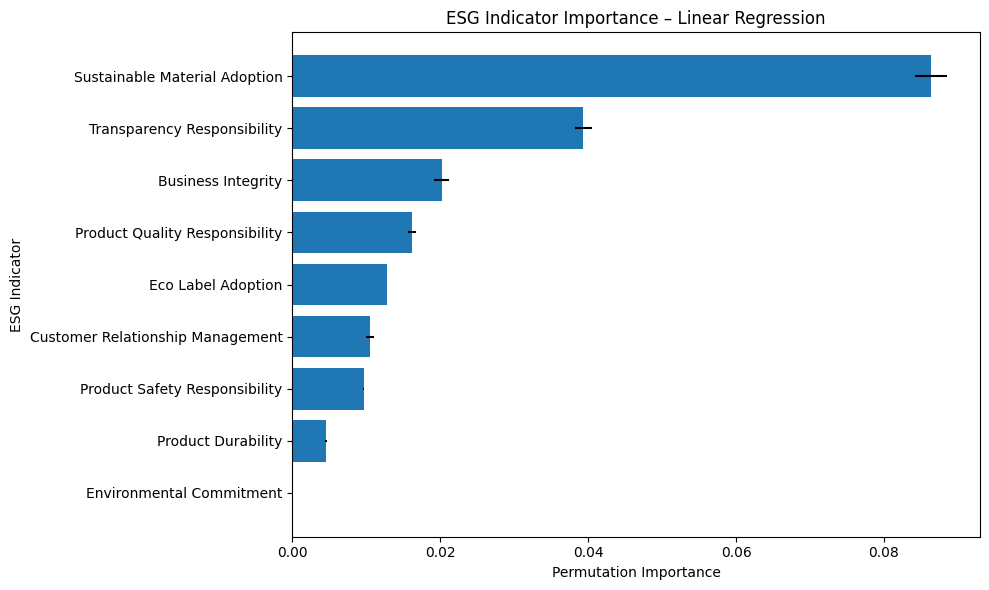

In [113]:
plot_df = feature_importance_df.sort_values(
    "importance_mean",
    ascending=True,
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["indicator"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
)

plt.xlabel("Permutation Importance")
plt.ylabel("ESG Indicator")
plt.title(
    f"ESG Indicator Importance – {best_model_name}"
)

plt.tight_layout()
plt.show()

In [114]:
comparison_df = feature_importance_df[
    [
        "indicator",
        "dimension",
        "global_weight",
        "importance_normalized",
    ]
].copy()

comparison_df = comparison_df.rename(
    columns={
        "global_weight": "AHP_weight",
        "importance_normalized": "ML_importance",
    }
)

display(comparison_df)

,indicator,dimension,AHP_weight,ML_importance
0,Sustainable Material Adoption,Environmental,0.266238,0.432705
1,Transparency Responsibility,Governance,0.077703,0.197047
2,Business Integrity,Governance,0.155407,0.101090
3,Product Quality Responsibility,Social,0.078320,0.081169
4,Eco Label Adoption,Environmental,0.146517,0.064274
5,Customer Relationship Management,Governance,0.077703,0.052625
6,Product Safety Responsibility,Social,0.078320,0.048341
7,Product Durability,Social,0.039160,0.022748
8,Environmental Commitment,Environmental,0.080631,0.000000


In [115]:
from scipy.stats import spearmanr

spearman_correlation, spearman_p_value = spearmanr(
    comparison_df["AHP_weight"],
    comparison_df["ML_importance"],
)

print(
    "Spearman correlation:",
    round(spearman_correlation, 4),
)

print(
    "p-value:",
    round(spearman_p_value, 4),
)

Spearman correlation: 0.4167
p-value: 0.2646


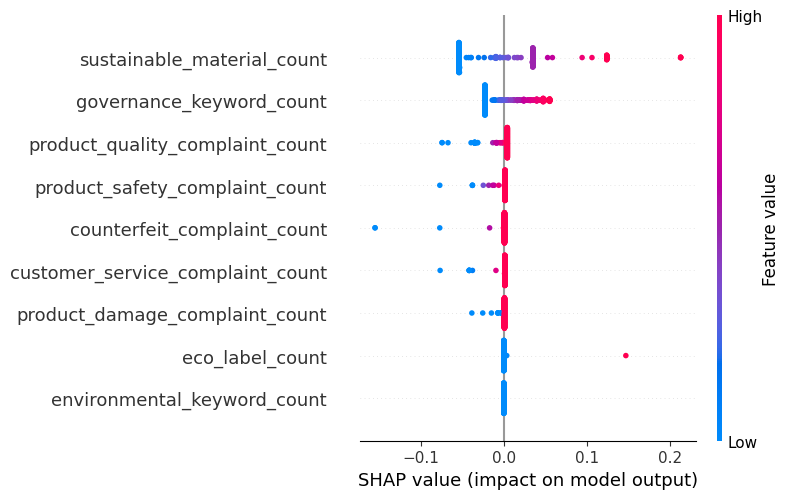

In [116]:
try:
    import shap

    underlying_model = final_model.named_steps["model"]
    transformed_X = final_model.named_steps[
        "imputer"
    ].transform(X)

    transformed_X_df = pd.DataFrame(
        transformed_X,
        columns=X.columns,
        index=X.index,
    )

    if best_model_name in [
        "Linear Regression",
        "Ridge Regression",
    ]:
        explainer = shap.LinearExplainer(
            underlying_model,
            transformed_X_df,
        )

        shap_values = explainer(
            transformed_X_df
        )

        shap.summary_plot(
            shap_values,
            transformed_X_df,
            feature_names=X.columns,
        )
    else:
        explainer = shap.LinearExplainer(
            underlying_model,
            transformed_X_df,
        )
        shap_values = explainer.shap_values(
            transformed_X_df
        )

        shap.summary_plot(
            shap_values,
            transformed_X_df,
            feature_names=X.columns,
        )

except ImportError:
    print(
        "SHAP is not installed. Run: pip install shap"
    )
except Exception as error:
    print("SHAP analysis could not be completed:", error)

In [117]:
feature_importance_df.to_csv(
    IMPORTANCE_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", IMPORTANCE_OUTPUT_PATH)

Saved: d:\UNI\NCKH\CTD2026_DT049\ESG_Modeling\feature_importance.csv


In [118]:
model_package = {
    "model_name": best_model_name,
    "model": final_model,
    "feature_names": esg_features,
    "seller_column": seller_column,
    "reference_imputer": imputer,
    "reference_scaler": scaler,
    "indicator_mapping": indicator_mapping,
    "indicator_weights": indicator_weight_df,
    "dimension_weights": dimension_weight_dict,
    "negative_direction_features": negative_direction_features,
    "random_state": RANDOM_STATE,
}

In [119]:
with open(MODEL_OUTPUT_PATH, "wb") as file:
    pickle.dump(model_package, file)

print("Saved:", MODEL_OUTPUT_PATH)

Saved: d:\UNI\NCKH\CTD2026_DT049\ESG_Modeling\seller_esg_model.pkl


In [120]:
AHP_CONSISTENCY_PATH = (
    OUTPUT_DIR / "ahp_consistency_results.csv"
)

consistency_results.to_csv(
    AHP_CONSISTENCY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", AHP_CONSISTENCY_PATH)

Saved: d:\UNI\NCKH\CTD2026_DT049\ESG_Modeling\ahp_consistency_results.csv


In [121]:
metadata = {
    "notebook": "Notebook 06 - Seller ESG Modeling",
    "target": "ESG_reference_score",
    "features": esg_features,
    "best_model": best_model_name,
    "random_state": RANDOM_STATE,
    "number_of_sellers": int(len(X)),
    "number_of_features": int(len(esg_features)),
    "output_files": [
        MAPPING_OUTPUT_PATH.name,
        WEIGHT_OUTPUT_PATH.name,
        REFERENCE_OUTPUT_PATH.name,
        PERFORMANCE_OUTPUT_PATH.name,
        IMPORTANCE_OUTPUT_PATH.name,
        MODEL_OUTPUT_PATH.name,
        AHP_CONSISTENCY_PATH.name,
    ],
}

METADATA_OUTPUT_PATH = OUTPUT_DIR / "model_metadata.json"

with open(
    METADATA_OUTPUT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=4,
    )

print("Saved:", METADATA_OUTPUT_PATH)

Saved: d:\UNI\NCKH\CTD2026_DT049\ESG_Modeling\model_metadata.json


In [122]:
output_summary = []

for output_file in sorted(OUTPUT_DIR.iterdir()):
    if output_file.is_file():
        output_summary.append(
            {
                "file": output_file.name,
                "size_kb": round(
                    output_file.stat().st_size / 1024,
                    2,
                ),
            }
        )

output_summary_df = pd.DataFrame(output_summary)

display(output_summary_df)

,file,size_kb
0,ahp_consistency_results.csv,0.41
1,ahp_indicator_mapping.csv,0.64
2,feature_importance.csv,1.42
3,indicator_weight.csv,1.18
4,model_metadata.json,0.87
5,model_performance.csv,1.13
6,seller_esg_model.pkl,7.67
7,seller_esg_reference_dataset.csv,32.11
